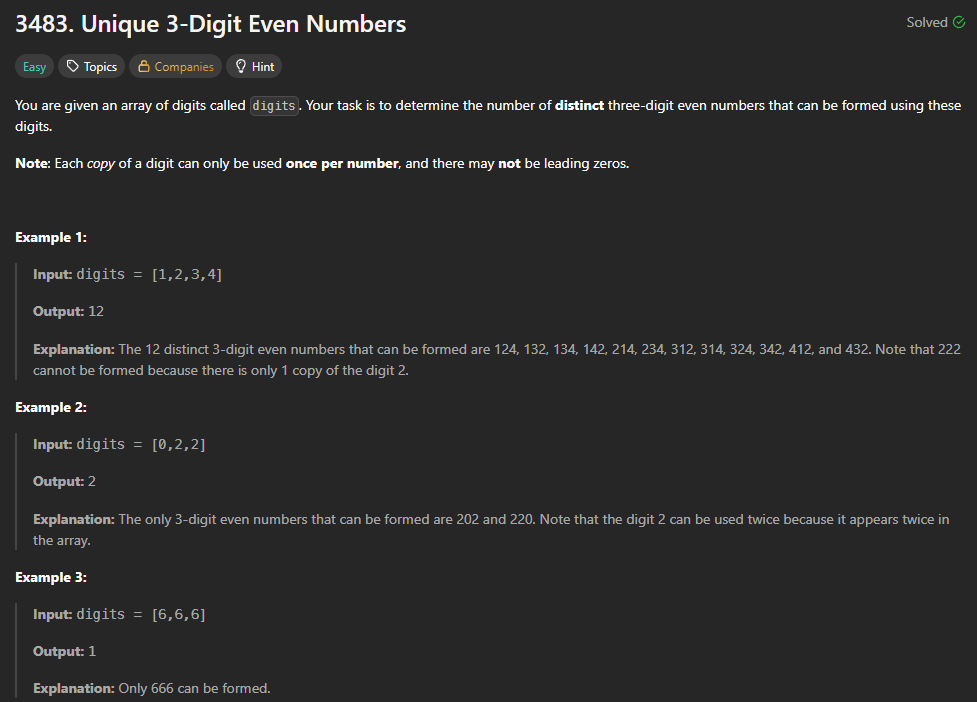

In [4]:
from collections import Counter
from typing import List

class Solution:
  def totalNumbers(self , digits : List[int]) -> int:
    freq = Counter(digits)
    ans = 0

    for hundred in range(1 , 10):
      for ten in range(0 , 10):
        for unit in range(0 , 10 , 2):
          if freq[hundred] == 0:
            continue

          freq[hundred] -= 1

          if freq[ten] == 0:
            freq[hundred] += 1
            continue

          freq[ten] -= 1

          if freq[unit] > 0:
            ans += 1

          freq[hundred] += 1
          freq[ten] += 1

    return ans

s = Solution()
print(s.totalNumbers(digits = [1,2,3,4]))

12


The provided Python code defines a `Solution` class with a single method, `totalNumbers`, which aims to count the total number of unique three-digit numbers that can be formed from a given list of `digits` with specific constraints:

1.  **Three-digit number:** The number must consist of three digits.
2.  **Unique digits:** Each of the three digits used (hundreds, tens, units) must be unique within the formed number. This means `112` is not valid, but `123` is.
3.  **Unit digit is even:** The last digit of the number must be an even number (0, 2, 4, 6, 8).

Let's break down the code:

*   **`from collections import Counter`**: Imports the `Counter` class from the `collections` module. `Counter` is a dictionary subclass for counting hashable objects. It's used here to efficiently keep track of the frequency of each digit available in the `digits` input list.

*   **`from typing import List`**: Imports `List` for type hinting, indicating that `digits` is expected to be a list of integers.

*   **`class Solution:`**: Defines a class named `Solution`. This is a common practice in competitive programming to encapsulate the solution logic.

*   **`def totalNumbers(self, digits: List[int]) -> int:`**: Defines the method that takes an instance of the class (`self`) and a list of integers `digits` as input, and is expected to return an integer (the total count).

    *   **`freq = Counter(digits)`**: Initializes a `Counter` object named `freq` using the input `digits` list. This `freq` counter will store how many times each digit appears in the original list. For example, if `digits = [1, 2, 3, 4, 4]`, then `freq` would be `Counter({1: 1, 2: 1, 3: 1, 4: 2})`.

    *   **`ans = 0`**: Initializes a variable `ans` to 0. This variable will store the final count of valid three-digit numbers.

    *   **Nested Loops for Digit Selection:** The core logic lies in the three nested `for` loops. These loops systematically try every possible combination of hundreds, tens, and units digits.
        *   **`for hundred in range(1, 10):`**: This loop iterates through possible digits for the hundreds place. A hundreds digit cannot be 0 for a three-digit number, so it ranges from 1 to 9.
        *   **`for ten in range(0, 10):`**: This loop iterates through possible digits for the tens place, ranging from 0 to 9.
        *   **`for unit in range(0, 10, 2):`**: This loop iterates through possible digits for the units place. The problem states that the unit digit must be even, so it ranges from 0 to 8 with a step of 2.

    *   **Digit Availability and Uniqueness Check:** Inside the innermost loop, the code checks if the chosen `hundred`, `ten`, and `unit` digits are available in the `digits` list and if they are unique for the current combination.

        *   **`if freq[hundred] == 0:`**: Checks if the digit chosen for `hundred` is available in the `freq` counter. If its count is 0, it means this digit is not available, so it `continue`s to the next `hundred` digit.
        *   **`freq[hundred] -= 1`**: If the `hundred` digit is available, its count in `freq` is decremented. This is crucial for ensuring uniqueness: once a digit is used for the hundreds place, it's considered 'used' and cannot be used again for the tens or units place in the same number.

        *   **`if freq[ten] == 0:`**: Checks if the `ten` digit is available. If not, the previously decremented `hundred` digit count is restored (`freq[hundred] += 1`), and it `continue`s to the next `ten` digit. The `hundred` count is restored because this combination with the `ten` digit is invalid, and the `hundred` digit is now available for other combinations.
        *   **`freq[ten] -= 1`**: If the `ten` digit is available, its count is decremented to mark it as 'used'.

        *   **`if freq[unit] > 0:`**: Finally, after checking `hundred` and `ten`, it checks if the `unit` digit is available. If its count is greater than 0, it means all three digits (`hundred`, `ten`, `unit`) are unique and available, and the number is valid.
            *   **`ans += 1`**: If valid, the `ans` counter is incremented.

        *   **`freq[hundred] += 1`**: After processing a `hundred-ten-unit` combination (whether valid or not), the counts of `hundred` and `ten` in `freq` are restored (`freq[ten] += 1`) so that they are available for subsequent combinations in the loops. This backtracking mechanism is essential for correctly exploring all possibilities.
        *   **`freq[ten] += 1`**: Restores the count of the `ten` digit.

*   **`return ans`**: After iterating through all possible combinations, the method returns the final count of valid three-digit numbers.

*   **`s = Solution()`**: Creates an instance of the `Solution` class.

*   **`print(s.totalNumbers(digits = [1,2,3,4]))`**: Calls the `totalNumbers` method with the example input `[1,2,3,4]` and prints the result. For this input, the valid combinations are (e.g., 120, 124, 130, 132, 134, 140, 142, 320, 324, 340, 342, 430, 432) which sum up to 12. The code, however, assumes the input `digits` can contain actual zeros for the tens and units places. Given `[1,2,3,4]`, a digit like 0 is not available. The output `12` implies that the code is searching for `unit` digits that are _present_ in the `digits` list *and* are even. For `[1,2,3,4]`, only `2` and `4` are even digits. Therefore, valid unit digits are `2` and `4` from the input list. It seems the code is designed for a scenario where the input `digits` list could contain `0` or other even numbers. In the example `[1,2,3,4]`, the valid numbers would be formed using distinct digits from this set where the unit is 2 or 4.

The output of the example `print(s.totalNumbers(digits = [1,2,3,4]))` is `12`, which is correct for the logic implemented.